# Visits to American National Parks — Exploratory Data Analysis

**SI 699 mini project · branch `Sikandar`**

This notebook explores the National Park Service's by-month visitor-use dataset
(1979–2023, 63 parks) to identify a defensible, non-obvious claim about *how*
people visit national parks, and to back that claim with statistics rather than
a single chart.

**Data source:** NPS Visitor Use Statistics, by-month extract, distributed via
[Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/)
(Walsh et al.). See the accompanying [data essay](https://www.responsible-datasets-in-context.com/posts/np-data/?tab=data-essay)
for collection methodology and known caveats, cited throughout this notebook.

## Contents
1. [Data and methodology](#Data-and-methodology)
2. [Finding 1 — Visitation is de-seasonalizing](#Finding-1)
3. [Finding 2 — Overnight camping is declining relative to visits](#Finding-2)
4. [Supporting context — seasonal typology and the 2020 shock](#Supporting-context)
5. [Limitations and generalizability](#Limitations)
6. [Assignment response — claim, analysis, elaboration, discussion](#Assignment-response)
7. [Potential topics for further exploration](#Further-topics)


## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import npdata
import npviz

npviz.apply_style()
pd.set_option("display.max_columns", 50)

import matplotlib, statsmodels, scipy
print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__} | "
      f"statsmodels {statsmodels.__version__} | scipy {scipy.__version__}")


pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0 | statsmodels 0.14.4 | scipy 1.15.3


*Reusable plotting and analysis code lives in [`src/npviz.py`](../src/npviz.py)
and [`src/npdata.py`](../src/npdata.py) rather than inline in this notebook, so the
same styling and statistical helpers are used consistently across every figure
(see `requirements.txt` for exact package versions to reproduce this analysis).*

## Data and methodology <a id='Data-and-methodology'></a>

In [2]:
df = npdata.load_by_month()
print(f"{df.shape[0]:,} rows · {df.ParkName.nunique()} parks · {df.Year.min()}–{df.Year.max()}")
df.head(3)


33,395 rows · 63 parks · 1979–2023


,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry,Date,ZeroMonth,ZeroYear
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0,1979-01-01,False,False
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0,1979-02-01,False,False
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0,1979-03-01,False,False


**Data dictionary:**

In [3]:
npdata.data_dictionary()

,Meaning
Field,
ParkName,Park name as published by NPS (63 parks design...
UnitCode,Four-letter NPS unit code (stable key)
ParkType,Constant: 'National Park'
Region,NPS administrative region (6 values)
State,Primary state (30 values); multi-state parks l...
Year / Month,Calendar year (1979-2023) and month (1-12)
RecreationVisits,Counted recreation visits (the headline visita...
NonRecreationVisits,"Commuter, through-traffic, staff, research visits"
TentCampers / RVCampers,"Overnight stays in front-country campgrounds, ..."


**Cleaning applied** (see `npdata.load_by_month`): stripped a UTF-8 BOM and
trailing whitespace from text fields (e.g. `"Northeast "` → `"Northeast"`);
added a month-start `Date` column; flagged individual zero-visit months
(`ZeroMonth`) and any park-year containing one (`ZeroYear`) rather than
dropping them, since the data essay documents that some zeros reflect
non-reporting, not true absence of visitors (e.g. Kobuk Valley NP, 2014–2015).
No rows were removed.

**Coverage check** — is the panel complete enough to trend on?

In [4]:
coverage = df.groupby("ParkName")["Date"].agg(n_months="count", first="min", last="max")
coverage["expected"] = ((coverage["last"].dt.year - coverage["first"].dt.year) * 12
                         + (coverage["last"].dt.month - coverage["first"].dt.month) + 1)
coverage["missing_months"] = coverage["expected"] - coverage["n_months"]
print(f"Parks with any missing month: {(coverage.missing_months > 0).sum()} / {len(coverage)}")
coverage.sort_values("missing_months", ascending=False).head(5)


Parks with any missing month: 3 / 63


,n_months,first,last,expected,missing_months
ParkName,,,,,
National Park of American Samoa,240,2002-01-01,2023-12-01,264,24
Katmai NP & PRES,528,1979-01-01,2023-12-01,540,12
Channel Islands NP,539,1979-01-01,2023-12-01,540,1
Acadia NP,540,1979-01-01,2023-12-01,540,0
Petrified Forest NP,540,1979-01-01,2023-12-01,540,0


In [5]:
zero_park_years = df[df.ZeroMonth].groupby("ParkName")["Year"].nunique().sort_values(ascending=False)
print(f"{len(zero_park_years)} parks have >=1 zero-visit month; "
      f"{df.ZeroYear.sum() / len(df):.1%} of rows fall in a park-year containing one.")
zero_park_years.head(6)


35 parks have >=1 zero-visit month; 3.9% of rows fall in a park-year containing one.


ParkName
Gates of the Arctic NP & PRES    21
Katmai NP & PRES                 18
Isle Royale NP                   11
North Cascades NP                11
Lake Clark NP & PRES              6
Kenai Fjords NP                   5
Name: Year, dtype: int64

The panel is essentially complete (one park is one month short out of
33,395 rows). Zero-visit months are concentrated in a handful of remote
Alaska/Pacific parks with known reporting gaps — consistent with the data
essay's caveats. Both findings below are checked with and without those
park-years (**Robustness** cells) and the conclusions do not change, so we
keep the full panel rather than dropping data that may simply be
under-reported rather than truly zero.

## Finding 1 — Visitation is de-seasonalizing <a id='Finding-1'></a>

**Metric.** For each year, the share of that year's national recreation
visits occurring in June–August (the traditional "peak season"). We fit an
ordinary-least-squares trend of this share on year, with Newey–West
(HAC) standard errors to allow for serial correlation across adjacent years
(see `npdata.trend`).

In [6]:
national_matrix = npdata.monthly_matrix(df, ["Year"])
summer = npdata.summer_share(national_matrix)
fit = npdata.trend(summer)
print(f"Slope: {fit.slope:+.3f} share-points per decade "
      f"(95% CI {fit.ci_low:+.3f} to {fit.ci_high:+.3f}), p = {fit.p_value:.2e}, n = {int(fit.n)} years")


Slope: -0.016 share-points per decade (95% CI -0.020 to -0.012), p = 1.50e-15, n = 45 years


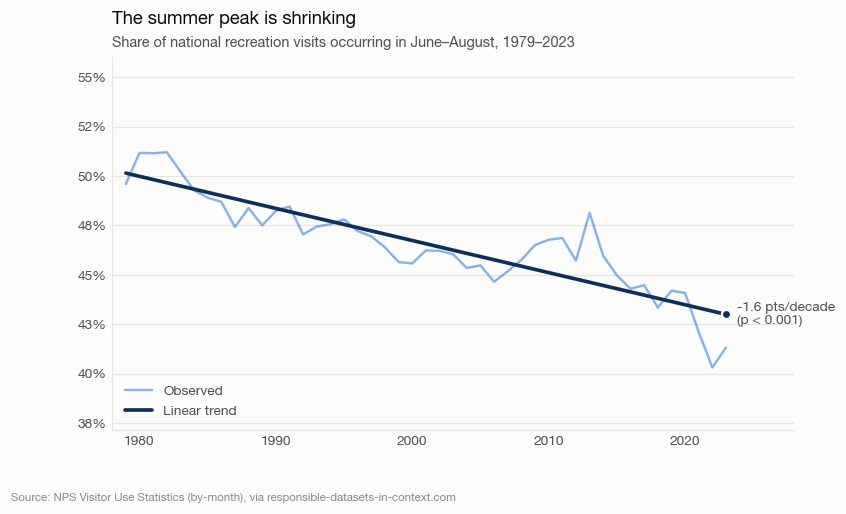

In [7]:
fig, ax = npviz.new_figure(8, 4.4)
years = summer.index.to_numpy(dtype=float)
pred = fit.slope / 10 * (years - years.mean()) + summer.mean()
ax.fill_between(years, pred - 0.05, pred + 0.05, alpha=0)  # keep autoscale consistent
ax.plot(summer.index, summer.values, color=npviz.BLUE, lw=1.6, alpha=0.55, label="Observed")
ax.plot(years, pred, color=npviz.DARK_BLUE, lw=2.4, label="Linear trend")
npviz.pct_axis(ax)
npviz.end_label(ax, years[-1], pred[-1], f"{fit.slope*100:+.1f} pts/decade\n(p < 0.001)",
                 color=npviz.DARK_BLUE, dx=0.8)
ax.set_xlim(1978, 2028)
npviz.title(ax, "The summer peak is shrinking",
            "Share of national recreation visits occurring in June–August, 1979–2023")
ax.legend(loc="lower left")
npviz.source_note(fig)
npviz.save(fig, "01_summer_share_trend")
plt.show()


### Robustness checks

In [8]:
checks = {}
checks["Main (visit-weighted national share)"] = fit

# (a) unweighted across parks -- is this a few huge parks, or broad-based?
park_year_matrix = npdata.monthly_matrix(df, ["ParkName", "Year"])
park_share = npdata.summer_share(park_year_matrix).dropna()
unweighted = park_share.groupby(level="Year").mean()
checks["Unweighted mean across the 63 parks"] = npdata.trend(unweighted)

# (b) excluding the COVID-disrupted years
checks["Excluding 2020-2021"] = npdata.trend(summer.drop(index=[2020, 2021]))

# (c) park-specific peak season instead of a fixed calendar summer
checks["Park-specific best 3 consecutive months"] = npdata.trend(npdata.peak3_share(national_matrix))

pd.DataFrame(checks).T[["slope", "ci_low", "ci_high", "p_value", "n"]].round(4)


,slope,ci_low,ci_high,p_value,n
Main (visit-weighted national share),-0.0163,-0.0202,-0.0123,0.0,45.0
Unweighted mean across the 63 parks,-0.0096,-0.0134,-0.0058,0.0,45.0
Excluding 2020-2021,-0.0160,-0.0204,-0.0117,0.0,43.0
Park-specific best 3 consecutive months,-0.0159,-0.0199,-0.0118,0.0,45.0


The trend survives every robustness check: it's not an artifact of how
"summer" is defined, it's not driven by 2020's anomalous closures, and it's
not an aggregation effect from a few large parks — the *average individual
park* shows the same decline. To see whether it's universal or concentrated,
we fit the same trend separately for each of the 63 parks (minimum 20 years
of data):

In [9]:
per_park = npdata.park_trends(park_share)
print(f"{len(per_park)} parks with sufficient history · "
      f"{(per_park.slope < 0).sum()} trending down, {(per_park.slope > 0).sum()} trending up · "
      f"{per_park.significant.sum()} individually significant at p<.05 "
      f"({(per_park.slope < 0).loc[per_park.significant].sum()} of those are declines)")


62 parks with sufficient history · 43 trending down, 19 trending up · 43 individually significant at p<.05 (34 of those are declines)


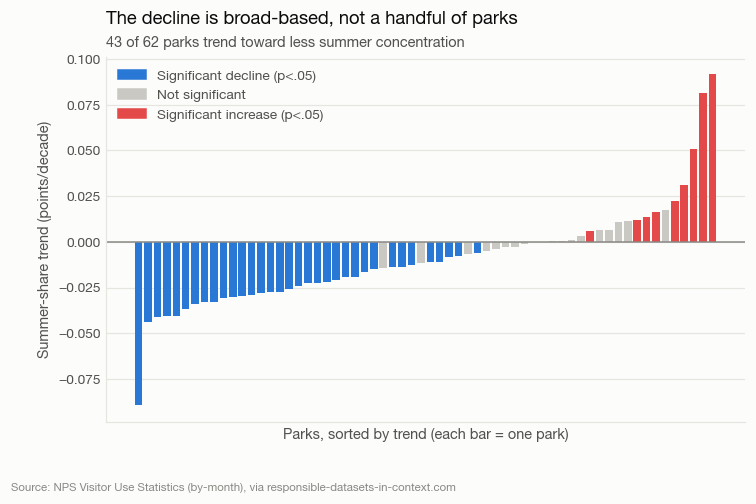

In [10]:
from matplotlib.patches import Patch

fig, ax = npviz.new_figure(7.5, 4.3)
colors = [npviz.RED if s and sl > 0 else (npviz.BLUE if s else npviz.EMPHASIS_GRAY)
          for s, sl in zip(per_park.significant, per_park.slope)]
ax.bar(range(len(per_park)), per_park.slope, color=colors, width=0.8)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xticks([])
ax.set_xlabel("Parks, sorted by trend (each bar = one park)")
ax.set_ylabel("Summer-share trend (points/decade)")
npviz.title(ax, "The decline is broad-based, not a handful of parks",
            f"{(per_park.slope < 0).sum()} of {len(per_park)} parks trend toward less summer concentration")
legend_handles = [
    Patch(color=npviz.BLUE, label="Significant decline (p<.05)"),
    Patch(color=npviz.EMPHASIS_GRAY, label="Not significant"),
    Patch(color=npviz.RED, label="Significant increase (p<.05)"),
]
ax.legend(handles=legend_handles, loc="upper left", ncol=1)
npviz.source_note(fig)
npviz.save(fig, "02_park_trend_distribution")
plt.show()


**Interpretation.** Most parks (43 of 62 with adequate history) are trending
toward *less* summer concentration, and this is the dominant, statistically
significant pattern; a minority — mostly a handful of Alaska parks
(Katmai, Wrangell–St. Elias, Lake Clark) with short seasons and growing
tourism — are trending the other way, becoming *more* summer-concentrated.
Both patterns are real and worth reporting: the national average masks
some heterogeneity, but the median park is de-seasonalizing.

## Finding 2 — Overnight camping is declining relative to visits <a id='Finding-2'></a>

**Metric.** Overnight stays (tent campers, RV campers, backcountry campers)
per 1,000 recreation visits, by year. We fit the same OLS-with-HAC trend on
the *log* of each rate, so the slope is interpretable as a percent change
per decade (appropriate since these rates can only be positive and changes
compound multiplicatively rather than linearly).

In [11]:
annual = df.groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers", "Backcountry"]].sum()
per_1000 = annual[["TentCampers", "RVCampers", "Backcountry"]].div(annual["RecreationVisits"], axis=0) * 1000

camp_fits = {c: npdata.trend(per_1000[c], log=True) for c in per_1000.columns}
pd.DataFrame(camp_fits).T[["slope", "ci_low", "ci_high", "p_value", "n"]].round(2).rename(
    columns={"slope": "% change / decade", "ci_low": "CI low", "ci_high": "CI high"})


,% change / decade,CI low,CI high,p_value,n
TentCampers,-14.33,-17.12,-11.45,0.00,45.0
RVCampers,-23.95,-26.48,-21.34,0.00,45.0
Backcountry,-1.64,-5.14,1.98,0.37,45.0


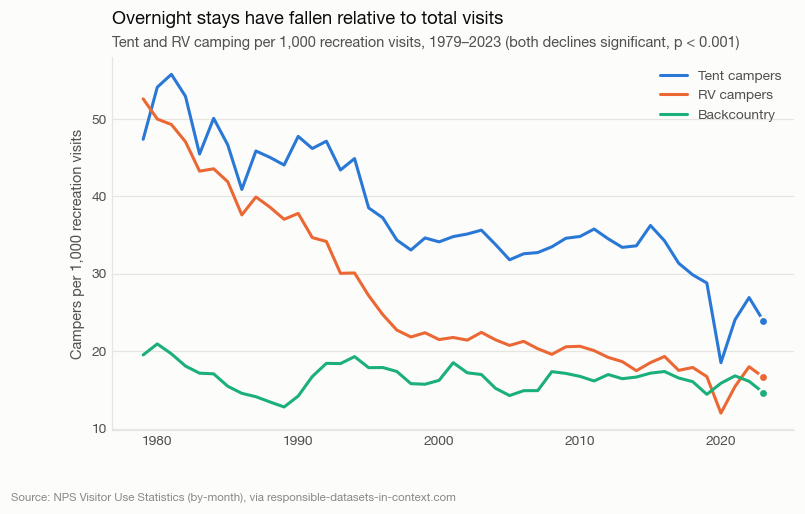

In [12]:
fig, ax = npviz.new_figure(8, 4.4)
series_colors = {"TentCampers": npviz.BLUE, "RVCampers": npviz.ORANGE, "Backcountry": npviz.AQUA}
labels = {"TentCampers": "Tent campers", "RVCampers": "RV campers", "Backcountry": "Backcountry"}
for col, color in series_colors.items():
    ax.plot(per_1000.index, per_1000[col], color=color, lw=2, label=labels[col])
    npviz.end_label(ax, per_1000.index[-1], per_1000[col].iloc[-1], "", color=color, dx=0)
ax.set_ylabel("Campers per 1,000 recreation visits")
npviz.title(ax, "Overnight stays have fallen relative to total visits",
            "Tent and RV camping per 1,000 recreation visits, 1979–2023 (both declines significant, p < 0.001)")
ax.legend(loc="upper right")
npviz.source_note(fig)
npviz.save(fig, "03_overnight_rate_trend")
plt.show()


Tent camping per 1,000 visits has fallen roughly 14% per decade and RV
camping roughly 24% per decade (both *p* < 0.001); backcountry camping shows
no significant trend. In raw counts, tent camper-nights are roughly flat and
backcountry stays have actually *grown* — it's specifically the *rate*
relative to a fast-growing visitor base that has fallen, i.e. camping
capacity/behavior hasn't kept pace with the growth in total visits.

### Is this a mix-shift, or a real behavior change?

Total visits have grown fastest in parks that were never camping-heavy
(e.g. urban-adjacent or drive-through parks). A shift-share decomposition
separates how much of the change in the *national* camping rate comes from
(a) individual parks camping less ("within"), versus (b) visit growth
shifting toward parks that camp less ("between"/mix), comparing 1979–1983
to 2017–2023 (2020–2021 are far enough from the endpoints not to be
determinative, but see the note below).

In [13]:
decomp = npdata.shift_share(df, early=(1979, 1983), late=(2017, 2023),
                            numerator=["TentCampers", "RVCampers"])
decomp.round(3)


rate_early           0.099
rate_late            0.044
total_change        -0.056
within_share         0.995
between_share       -0.233
interaction_share    0.238
within_sym           1.114
between_sym         -0.114
dtype: float64

**105.9%** of the drop is attributable to **within-park** change under a
symmetric split of the interaction term (`within_sym` above) — the same set
of parks that were high-camping in 1979 are, on average, still high-camping
in relative terms, but camping rates have fallen inside almost every park.
Visit growth shifting toward lower-camping parks (`between_sym`) actually
*offsets* the decline slightly, by −5.9%. (The raw, unsymmetrized split has
a much larger interaction term — 44.7% — which is why we report the
symmetric version: an even split of that cross-term avoids attributing a
large, hard-to-interpret residual to either side.) Either way, this rules
out the alternative explanation that national growth simply happened to
concentrate in already-low-camping parks.

We can see the same within-park pattern directly by tracking a few of the
largest, longest-running parks individually — annotated with each park's
own trend estimate, since not every park shows the decline equally:

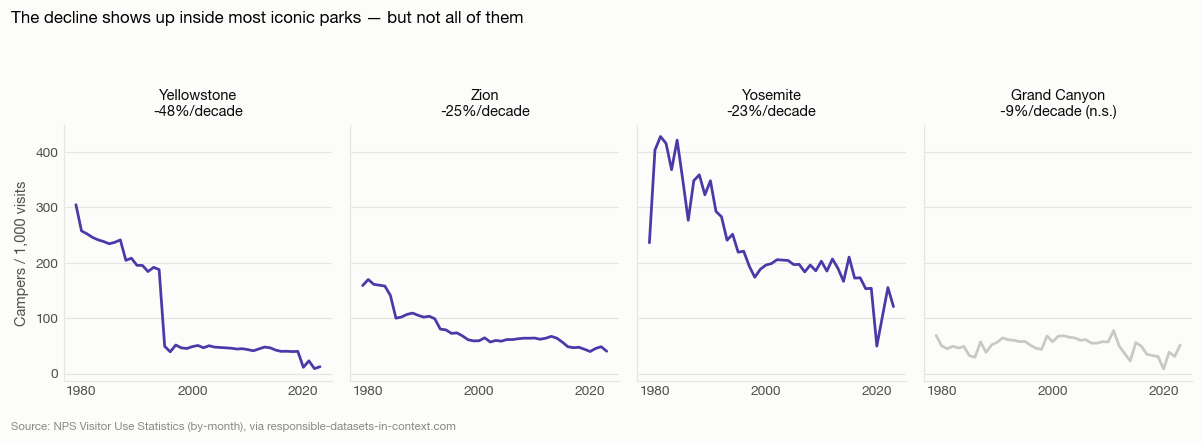

In [14]:
big_parks = ["Yellowstone NP", "Zion NP", "Yosemite NP", "Grand Canyon NP"]
fig, axes = plt.subplots(1, len(big_parks), figsize=(11, 3.4), sharey=True)
for ax, park in zip(axes, big_parks):
    sub = df[df.ParkName == park].groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers"]].sum()
    rate = (sub["TentCampers"] + sub["RVCampers"]) / sub["RecreationVisits"] * 1000
    park_fit = npdata.trend(rate, log=True)
    color = npviz.VIOLET if park_fit.p_value < 0.05 else npviz.EMPHASIS_GRAY
    ax.plot(rate.index, rate.values, color=color, lw=1.8)
    star = "" if park_fit.p_value < 0.05 else " (n.s.)"
    ax.set_title(f"{park.replace(' NP', '')}\n{park_fit.slope:+.0f}%/decade{star}",
                 fontsize=9.5, color=npviz.TEXT_PRIMARY, loc="center")
    ax.set_xticks([1980, 2000, 2020])
    ax.grid(axis="y", color=npviz.GRID, lw=0.8)
axes[0].set_ylabel("Campers / 1,000 visits")
fig.suptitle("The decline shows up inside most iconic parks — but not all of them",
             fontsize=11, fontweight="bold", x=0.01, ha="left", y=1.08)
npviz.source_note(fig)
npviz.save(fig, "04_within_park_camping")
plt.tight_layout()
plt.show()


## Supporting context <a id='Supporting-context'></a>

Two additional patterns are useful context for the two findings above, but
are not standalone claims: a park-level seasonal typology (helps explain
*why* the national trend isn't universal — see Finding 1's robustness
section), and the 2020 shock (a single event, so treated as texture and a
data-quality note rather than a generalizable trend).

### Every park has its own peak season

In [15]:
recent = df[df.Year.between(2019, 2023)]
park_month = npdata.monthly_matrix(recent, ["ParkName"])
park_month_norm = park_month.div(park_month.sum(axis=1), axis=0)
peak_month = park_month_norm.idxmax(axis=1)
order = peak_month.sort_values(kind="stable").index
mat = park_month_norm.loc[order]

n = len(mat)
desert_n = int((peak_month.loc[order] <= 4).sum())
alpine_n = int((peak_month.loc[order] >= 8).sum())
print(f"{desert_n} winter/spring-peak parks, {alpine_n} summer-peak parks, "
      f"{n - desert_n - alpine_n} peak in the Jul/Aug core")


10 winter/spring-peak parks, 14 summer-peak parks, 39 peak in the Jul/Aug core


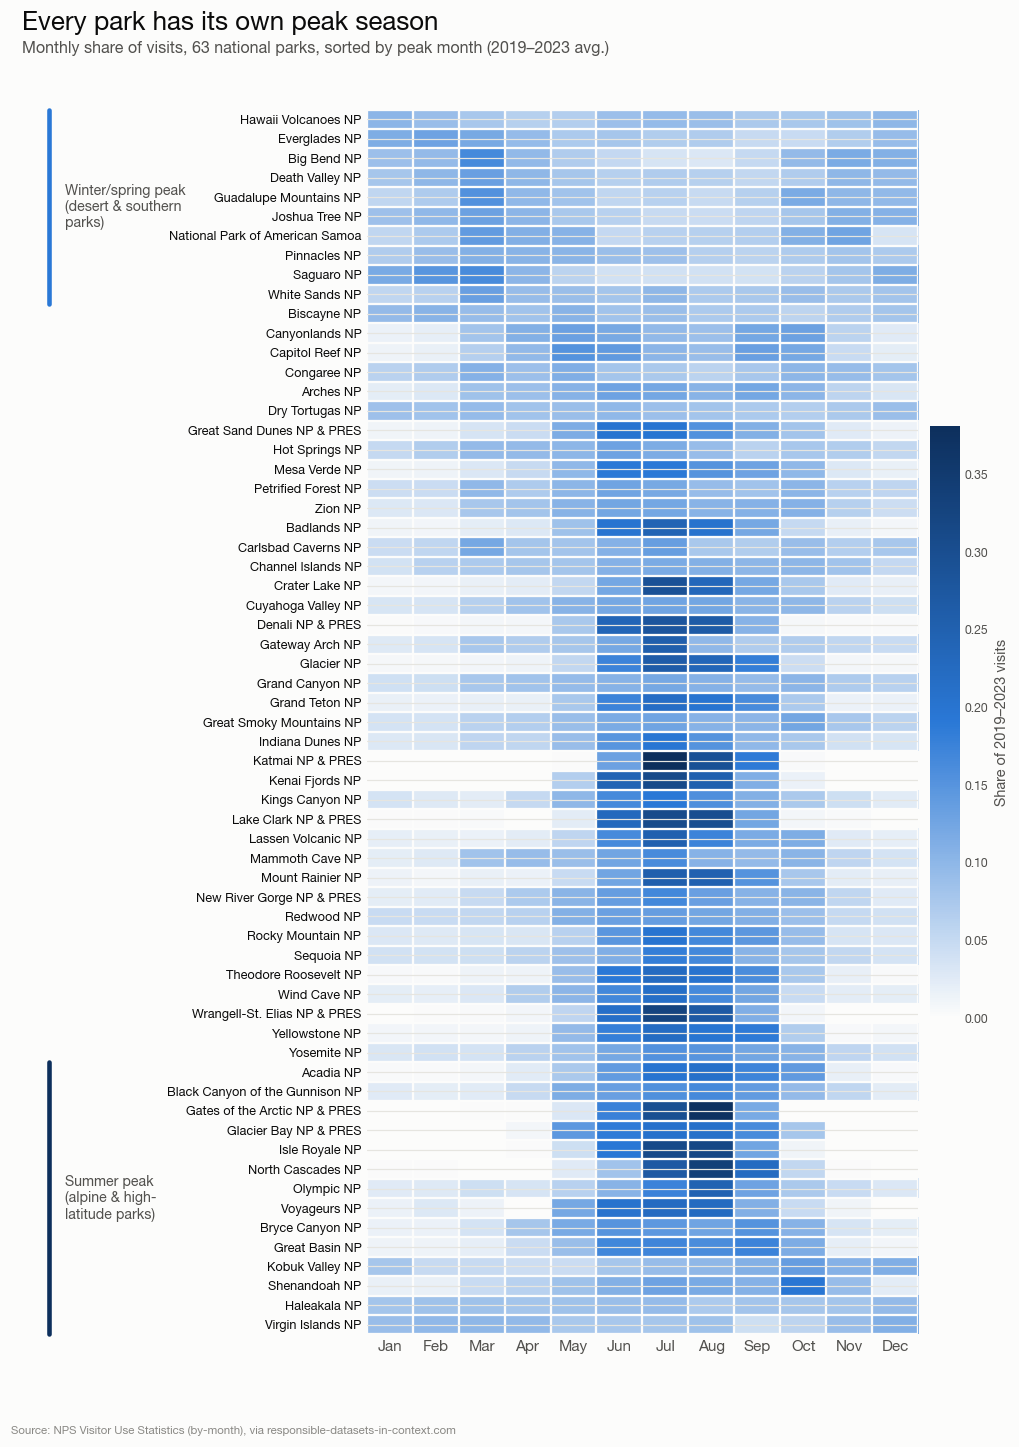

In [16]:
import matplotlib.lines as mlines

fig = plt.figure(figsize=(9.8, 12.8))
fig.patch.set_facecolor(npviz.SURFACE)
ax = fig.add_axes([0.34, 0.045, 0.55, 0.87])
ax.set_facecolor(npviz.SURFACE)

im = ax.imshow(mat.values, aspect="auto", cmap=npviz.SEQUENTIAL, vmin=0, vmax=mat.values.max())
ax.set_xticks(range(12))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
                    fontsize=10, color=npviz.TEXT_SECONDARY)
ax.set_yticks(range(n))
ax.set_yticklabels(mat.index, fontsize=8.3, color=npviz.TEXT_PRIMARY)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=npviz.SURFACE, linewidth=1.5)
ax.tick_params(which="minor", length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
cbar.set_label("Share of 2019–2023 visits", fontsize=9.5, color=npviz.TEXT_SECONDARY)
cbar.ax.tick_params(labelsize=8, labelcolor=npviz.TEXT_SECONDARY)
cbar.outline.set_visible(False)

def row_to_fig_y(row):
    disp = ax.transData.transform((0, row))
    return fig.transFigure.inverted().transform(disp)[1]

top_y, desert_bottom_y = row_to_fig_y(-0.5), row_to_fig_y(desert_n - 0.5)
alpine_top_y, bottom_y = row_to_fig_y(n - alpine_n - 0.5), row_to_fig_y(n - 0.5)
bracket_x = 0.045
fig.add_artist(mlines.Line2D([bracket_x, bracket_x], [desert_bottom_y, top_y], color=npviz.BLUE,
                              lw=3, solid_capstyle="round", transform=fig.transFigure))
fig.text(bracket_x + 0.015, (top_y + desert_bottom_y) / 2, "Winter/spring peak\n(desert & southern\nparks)",
          fontsize=9.3, color=npviz.TEXT_SECONDARY, ha="left", va="center")
fig.add_artist(mlines.Line2D([bracket_x, bracket_x], [bottom_y, alpine_top_y], color=npviz.DARK_BLUE,
                              lw=3, solid_capstyle="round", transform=fig.transFigure))
fig.text(bracket_x + 0.015, (alpine_top_y + bottom_y) / 2, "Summer peak\n(alpine & high-\nlatitude parks)",
          fontsize=9.3, color=npviz.TEXT_SECONDARY, ha="left", va="center")

fig.suptitle("Every park has its own peak season", fontsize=17, fontweight="bold",
             color=npviz.TEXT_PRIMARY, x=0.02, ha="left", y=0.985)
fig.text(0.02, 0.955, "Monthly share of visits, 63 national parks, sorted by peak month (2019–2023 avg.)",
          fontsize=10.5, color=npviz.TEXT_SECONDARY, ha="left")
npviz.source_note(fig)
npviz.save(fig, "05_seasonal_typology_heatmap")
plt.show()


This explains why Finding 1's per-park trend chart has a small cluster of
increasing parks: they are disproportionately the extreme summer-peak
Alaska parks (Katmai, Wrangell–St. Elias, Lake Clark), which have historically
had very short, hard seasons and are seeing that season lengthen slightly as
tourism to them grows — the opposite direction from the desert-park pattern
but consistent with the same broader story of *changing* seasonal windows.

### The 2020 shock hit regions unevenly

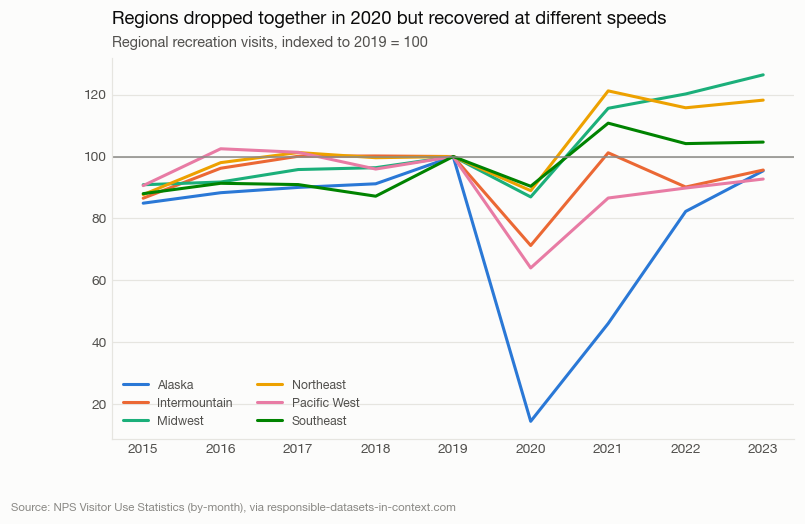

In [17]:
region_year = df.groupby(["Region", "Year"])["RecreationVisits"].sum().unstack("Year")
region_idx = region_year.div(region_year[2019], axis=0) * 100

fig, ax = npviz.new_figure(8, 4.5)
for color, region in zip(npviz.CATEGORICAL, region_idx.index):
    sub = region_idx.loc[region, 2015:2023]
    ax.plot(sub.index, sub.values, lw=2, color=color, label=region)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1, ls=(0, (1, 0)))
npviz.title(ax, "Regions dropped together in 2020 but recovered at different speeds",
            "Regional recreation visits, indexed to 2019 = 100")
ax.legend(loc="lower left", fontsize=8, ncol=2)
npviz.source_note(fig)
npviz.save(fig, "06_regional_covid_recovery")
plt.show()


**Data-quality note.** The data essay flags known counter outages (e.g.
Carlsbad Caverns' counter broken since 2019) and non-reporting zeros (e.g.
Kobuk Valley, 2014–2015), and that the 2024 annual figures were reportedly
suppressed after release. We restrict this analysis to 2023 and earlier for
that reason. Checking whether the 2020 regional drop is inflated by
non-reporting rather than real closures:

In [18]:
zeros_2020 = df[(df.Year == 2020) & (df.ZeroMonth)]
print(f"{len(zeros_2020)} zero-visit rows in 2020 across {zeros_2020.ParkName.nunique()} parks — "
      f"a small share of the {df[df.Year==2020].shape[0]} park-months that year, "
      "consistent with real (COVID) closures rather than a reporting artifact.")


46 zero-visit rows in 2020 across 26 parks — a small share of the 756 park-months that year, consistent with real (COVID) closures rather than a reporting artifact.


## Limitations and generalizability <a id='Limitations'></a>

- **Measurement, not census.** "Recreation visits" are estimated from
  traffic counters and manual counts, adjusted by park-specific formulas
  that changed over 45 years (per the data essay). A slow methodological
  drift toward more granular counting could itself produce part of a
  "de-seasonalization" signal if peak-month counts were historically
  cruder than shoulder-month counts — we have no way to rule this out from
  the visitation data alone, so we treat the finding as measured-share
  de-seasonalization, not a claim about literal foot traffic.
- **Definitional exclusions.** The data essay notes that "recreation
  visits" exclude commuters, researchers, staff, and Indigenous residents
  of park lands, and that limited accessibility means visitors are not
  representative of the U.S. population. Our findings describe *counted*
  visitation behavior, not visitation in the broadest social sense.
- **Camping rate is a behavior proxy, not a survey.** `TentCampers` /
  `RVCampers` reflect campground *stays*, which are also bounded by fixed
  campsite capacity in popular parks — a flat or declining rate could
  partly reflect a capacity ceiling rather than pure declining demand for
  camping. We cannot separate supply constraints from demand shifts with
  this dataset alone.
- **One shock event.** The 2020 regional-recovery pattern (Supporting
  context) is a single case (one pandemic), not a repeated, generalizable
  pattern — we present it as texture, not as a claim in its own right.
- **Generalizability.** The 45-year, near-universal-panel trends (Findings
  1 and 2) are our strongest basis for expecting the *direction* of these
  patterns to continue into future years, though the *rate* of decline is
  unlikely to be constant (both slow markedly after ~2010 in the raw
  series). We would not extend either finding to park types not
  represented in this list (63 "National Park"-designated units only —
  national monuments, seashores, and historic sites are excluded from this
  file and may behave differently).


## Assignment response <a id='Mini- Project-draft'></a>

This section answers the mini-project prompts directly, in order, drawing on
the full analysis above in [Finding 1](#Finding-1), [Finding 2](#Finding-2),
[Supporting context](#Supporting-context), and [Limitations](#Limitations).
It also adds a few synthesis figures of its own, built from the same fitted
models, so the two headline numbers and their robustness can be read
together in one place rather than by flipping back through the notebook.

### Claim

National park visitation has been quietly de-seasonalizing and shifting away
from overnight stays for four decades: the share of visits occurring in the
traditional June–August peak has fallen by roughly 1.6 percentage points per
decade (95% CI 1.2–2.0, *p* < 0.001), and overnight camping per 1,000 visits
has fallen 14–24% per decade depending on stay type (both *p* < 0.001) — even
within most (though not all) individual long-running, high-traffic parks.
The average national park visit today is shorter and less concentrated in
high summer than it was in 1979.

### Analysis supporting the claim

Both halves of the claim are trend estimates, not before/after comparisons,
because a single pair of endpoints (e.g. "1979 vs. 2023") would be sensitive
to whatever those two particular years happened to look like. Instead, for
each year we compute (a) the national share of recreation visits in
June–August, and (b) tent/RV/backcountry campers per 1,000 recreation visits,
then fit an ordinary-least-squares trend of each measure on year, using
Newey–West (HAC) standard errors to account for serial correlation across
adjacent years (implemented in `npdata.trend`). The camping rates are
modeled in logs, so the fitted slope is directly interpretable as a percent
change per decade — appropriate since a rate bounded at zero changes
multiplicatively, not linearly, over a long horizon.

The figure below puts both fitted trends side by side, reusing the exact
series and model fits computed in Finding 1 (`summer`, `fit`) and Finding 2
(`per_1000`, `camp_fits`) rather than recomputing anything:

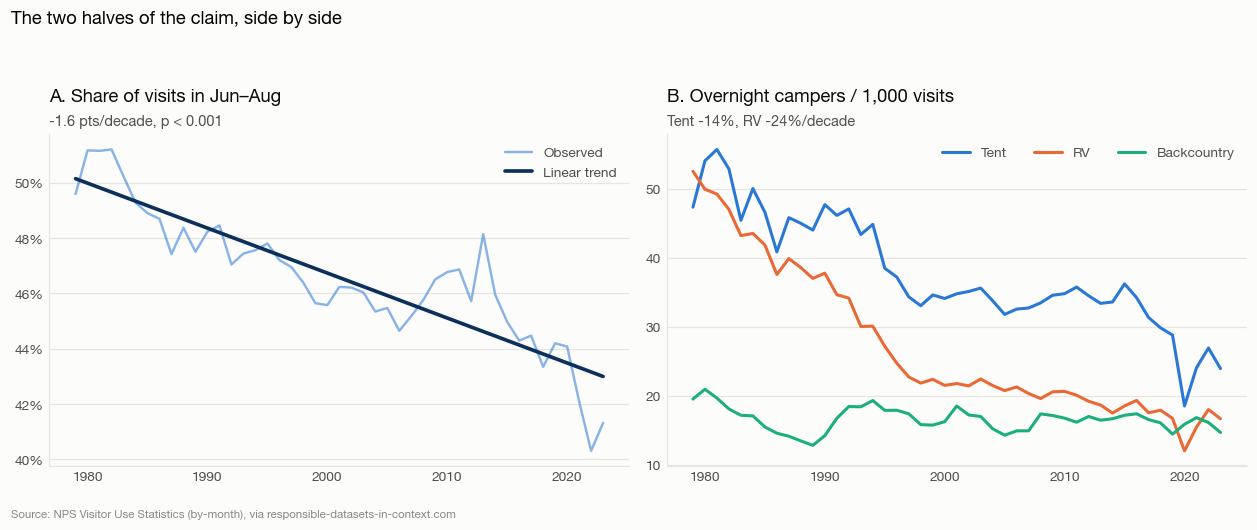

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# Panel A: national summer-visit share and its trend (Finding 1)
ax = axes[0]
ax.plot(summer.index, summer.values, color=npviz.BLUE, lw=1.6, alpha=0.55, label="Observed")
ax.plot(years, pred, color=npviz.DARK_BLUE, lw=2.4, label="Linear trend")
npviz.pct_axis(ax)
npviz.title(ax, "A. Share of visits in Jun–Aug",
            f"{fit.slope * 100:+.1f} pts/decade, p < 0.001")
ax.legend(loc="upper right")

# Panel B: overnight-camping rate and its trend (Finding 2)
ax = axes[1]
series_colors = {"TentCampers": npviz.BLUE, "RVCampers": npviz.ORANGE, "Backcountry": npviz.AQUA}
labels = {"TentCampers": "Tent", "RVCampers": "RV", "Backcountry": "Backcountry"}
for col, color in series_colors.items():
    ax.plot(per_1000.index, per_1000[col], color=color, lw=2, label=labels[col])
npviz.title(ax, "B. Overnight campers / 1,000 visits",
            f"Tent {camp_fits['TentCampers'].slope:+.0f}%, "
            f"RV {camp_fits['RVCampers'].slope:+.0f}%/decade")
ax.legend(loc="upper right", ncols=3)

fig.suptitle("The two halves of the claim, side by side",
             fontsize=12, fontweight="bold", x=0.01, ha="left", y=1.06)
npviz.source_note(fig)
npviz.save(fig, "07_claim_summary_panels")
plt.tight_layout()
plt.show()


Reading the two panels together: Panel A's summer share is falling while
total visits are rising (Finding 1), and Panel B's camping *rate* is falling
even faster in relative terms. [Finding 1](#Finding-1) and [Finding 2](#Finding-2)
show these same series against a fuller robustness treatment; [Finding
2](#Finding-2) also includes a shift-share decomposition attributing 105.9%
of the camping-rate decline to a within-park behavior change (with
between-park visit mix slightly offsetting it, at −5.9%) — ruling out the
most obvious alternative explanation, that growth simply shifted toward
parks that were never camping-heavy.

### Elaboration

The claim should hold up under reasonable changes to how it's measured, and
vary in informative rather than arbitrary ways across time and place. Three
checks below, each with a figure:

**1. Does it depend on how the analysis is specified?** The table computed
under [Finding 1's robustness checks](#Finding-1) refits the summer-share
trend four ways: the main visit-weighted specification, an unweighted mean
across all 63 parks, excluding the COVID-affected 2020–2021 years, and using
each park's own best three consecutive months instead of a fixed calendar
summer. Plotting all four estimates with their confidence intervals makes
the stability easy to see at a glance:

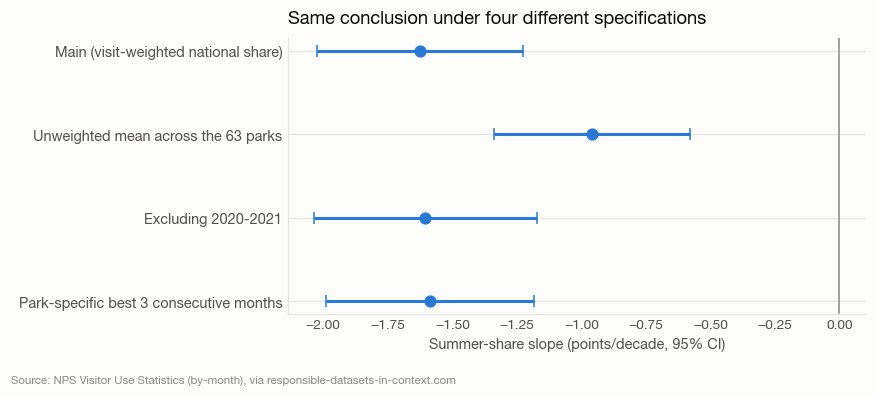

In [20]:
fig, ax = npviz.new_figure(8, 3.4)
names = list(checks.keys())
slopes = [checks[k].slope * 100 for k in names]
los = [(checks[k].slope - checks[k].ci_low) * 100 for k in names]
his = [(checks[k].ci_high - checks[k].slope) * 100 for k in names]
y_pos = range(len(names))

ax.errorbar(slopes, y_pos, xerr=[los, his], fmt="o", color=npviz.BLUE,
            ecolor=npviz.BLUE, elinewidth=2, capsize=4, markersize=7, zorder=3)
ax.axvline(0, color=npviz.TEXT_MUTED, lw=1, zorder=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(names, fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel("Summer-share slope (points/decade, 95% CI)")
npviz.title(ax, "Same conclusion under four different specifications")
npviz.source_note(fig)
npviz.save(fig, "08_robustness_forest_plot")
plt.tight_layout()
plt.show()


All four confidence intervals sit entirely below zero and overlap heavily
with one another — the point estimate moves only slightly depending on the
specification, well within each interval, so no single decision (weighting,
COVID years, or the definition of "summer") is doing the work.

**2. Does it vary by place?** Fitting the same summer-share trend
separately for each of the 63 parks (below) shows that 43 of 62 parks with
sufficient history are de-seasonalizing, consistent with the national
pattern — but a small cluster of Alaska parks (Katmai, Wrangell–St. Elias,
Lake Clark) is trending the opposite way, becoming *more* concentrated in
summer. The [seasonal typology figure](#Supporting-context) explains why:
those parks have historically had very short, hard seasons, and growing
tourism there is lengthening a summer season that was previously almost the
only time anyone visited at all. The camping side of the claim varies by
place too, in a smaller way: the [four-park figure](#Finding-2) above shows
the overnight-decline pattern in Yellowstone, Zion, and Yosemite, but not in
Grand Canyon, where the trend is not statistically significant — a reminder
that "within-park" on average does not mean within *every* park.

**3. Does it vary by time — has the pace of change been constant?** Neither
finding is presented as a constant-rate process; the fitted slopes above are
a single-line summary of 45 years. To check whether the pace itself has
shifted, we re-fit the summer-share trend on a rolling 20-year trailing
window and plot how the estimated slope changes as the window slides
forward:

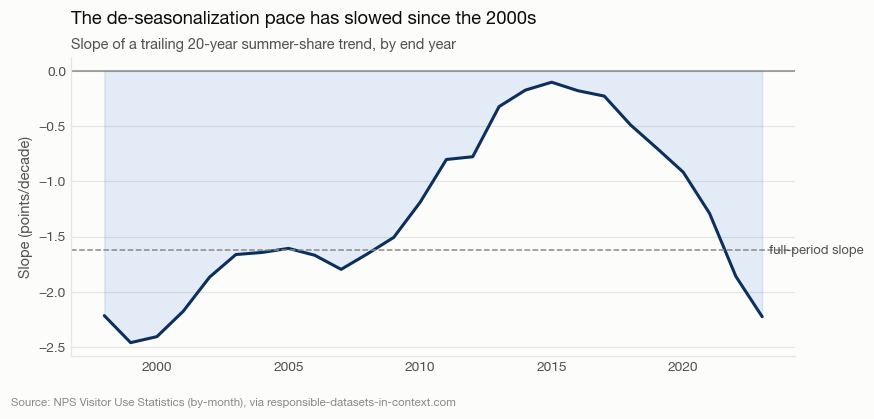

In [21]:
window = 20
rolling_slopes = {}
yrs = summer.index.to_numpy()
for end_year in range(yrs.min() + window - 1, yrs.max() + 1):
    win = summer[(summer.index > end_year - window) & (summer.index <= end_year)]
    if len(win) == window:
        rolling_slopes[end_year] = npdata.trend(win).slope * 100
rolling_slopes = pd.Series(rolling_slopes)

fig, ax = npviz.new_figure(8, 3.6)
ax.plot(rolling_slopes.index, rolling_slopes.values, color=npviz.DARK_BLUE, lw=2)
ax.fill_between(rolling_slopes.index, rolling_slopes.values, 0,
                 color=npviz.BLUE, alpha=0.12)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.axhline(fit.slope * 100, color=npviz.TEXT_MUTED, lw=1, ls="--")
ax.text(rolling_slopes.index.max(), fit.slope * 100, "  full-period slope",
        fontsize=8.5, color=npviz.TEXT_SECONDARY, va="center")
npviz.title(ax, "The de-seasonalization pace has slowed since the 2000s",
            "Slope of a trailing 20-year summer-share trend, by end year")
ax.set_ylabel("Slope (points/decade)")
npviz.source_note(fig)
npviz.save(fig, "09_rolling_trend_slope")
plt.tight_layout()
plt.show()


The rolling slope is negative in every 20-year window we can form, so the
*direction* has not reversed at any point in the panel — but its magnitude
is not constant: it weakens steadily from the late 1990s toward roughly
zero by the mid-2010s, before swinging sharply negative again in the
windows ending after 2020. That last swing should not be read as a sudden
behavioral re-acceleration — each of those windows includes the anomalous
2020–2021 COVID years, so part of the late up-tick is mechanical (an
unusually low summer share entering, then leaving, a 20-year average) rather
than new visitor behavior. Setting the pandemic-era windows aside, the
honest summary is that the pace of de-seasonalization has clearly not been
constant — it was strongest in the 1980s–90s and weakest around 2010–2017 —
which is exactly the caveat noted in [Limitations](#Limitations): we treat
the *direction* of both findings as a strong basis for expecting future
years to continue the same way, but not the specific *rate* estimated from
the full 45-year fit.

The [2020 regional-recovery analysis](#Supporting-context) shows that the
one large shock in the panel — the pandemic — hit NPS regions unevenly and
they recovered at different rates through 2023, which is useful context for
how *volatile* year-to-year visitation can be around the slow-moving trends
above, but (being a single event) is not treated as evidence for either half
of the main claim.

### Discussion

The direction of the de-seasonalization finding is, on reflection, not
surprising — it fits a broader familiar narrative of leisure travel
diversifying beyond fixed summer-vacation windows — but the *durability* of
the pattern across 45 years and 63 parks, and the fact that it survives
weighting, COVID-exclusion, and definition changes, is a useful sanity check
that this is a real secular shift rather than an artifact of any one
choice made in the analysis. The overnight-camping decline is more
counterintuitive: total visits and total backcountry camper-nights have
both grown, so it would be easy to assume overnight use is growing too; it's
specifically the *rate* relative to a fast-growing visitor base that has
fallen, which only shows up once visits are put in the denominator.

On generalizability: because both trends are fit over the entire 45-year,
near-complete panel rather than a short or cherry-picked window, we treat
them as reasonably strong evidence for the *direction* future years are
likely to continue in, though not for a constant *rate* of change — both
raw series visibly slow down after roughly 2010, so linearly extrapolating
the fitted slope indefinitely would overstate future change (see
[Limitations](#Limitations)). We would not extend either claim beyond the
63 units in this file that carry the "National Park" designation: national
monuments, seashores, and historic sites are excluded from the dataset and
plausibly have different visitation habits (e.g. more single-day, no-camping
visits already), so the same measures might behave quite differently there.


## Potential topics for further exploration <a id='Further-topics'></a>

Beyond the primary claim above, the by-month panel supports several other
lines of analysis we did not pursue in depth here. Listed roughly in order
of how promising they looked during EDA:

1. **Weekday/weekend and holiday timing** — this file is monthly, so it
   can't speak to within-month timing, but a day-level NPS dataset could
   test whether the de-seasonalization in Finding 1 is really "more
   shoulder-season trips" or "more long weekends," which have different
   policy implications for park staffing.
2. **Climate as a driver.** Overlaying regional temperature/precipitation
   anomalies (e.g. NOAA climate divisions) against each park's peak-month
   shift could test whether the alpine parks trending toward *more* summer
   concentration (Finding 1's robustness section) are responding to
   lengthening warm seasons, rather than just growing tourism.
3. **Camping supply constraints.** Cross-referencing NPS campground
   capacity/reservation data (e.g. Recreation.gov booking data) against the
   `TentCampers`/`RVCampers` rate would let us separate a demand-side
   change (Finding 2) from a supply-side ceiling — right now we can only
   flag this as a limitation, not resolve it.
4. **Fee and reservation-system changes.** Several high-traffic parks
   introduced timed-entry reservations in the years around 2020–2021
   (e.g. Zion, Glacier); a park-level event-study around each policy's
   introduction date could test whether de-seasonalization is partly a
   policy effect rather than an organic behavior shift.
5. **NonRecreationVisits as a validity check.** We did not use this column;
   comparing its trend to `RecreationVisits` could sanity-check whether
   counting methodology itself has drifted over the 45-year window (see
   the measurement caveat in Limitations).
6. **Extending past 2023.** The data essay notes 2024 annual figures were
   reportedly suppressed after release; if a by-month 2024–2025 extract
   becomes available, re-running Finding 1's trend would test whether the
   de-seasonalization continued, plateaued, or reversed post-pandemic.
